In [22]:

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment


np.random.seed(42)


print("=" * 60)
print("PHASE 1: DATASET AND CLUSTERING")
print("=" * 60)
print("\n1-a) Dataset: DIABETES (Pima Indians)")
print("-" * 40)

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

X = df.iloc[:, :-1].values      # Features (768, 8)
y_true = df.iloc[:, -1].values  # NOT used in clustering!
n_clusters = 2                   # Binary: diabetic / non-diabetic

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {n_clusters}")
print(f"Class distribution: {np.bincount(y_true)}")
print(f"Feature types: Integer + Real (mixed)")


# Function: Clustering Accuracy

def clustering_accuracy(y_true, y_pred):
    """
    Calculate accuracy using Hungarian algorithm
    to find optimal cluster-to-class mapping.
    """
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / len(y_true) * 100



# 1-b) K-Means Clustering

print("\n1-b) Running Clustering Algorithms")
print("-" * 40)

print("\n[K-Means Clustering]")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)  # NO y_true used!
kmeans_acc = clustering_accuracy(y_true, kmeans_labels)

print(f"Cluster distribution: {np.bincount(kmeans_labels)}")
print(f"K-Means Accuracy: {kmeans_acc:.2f}%")



# 1-b) Hierarchical Clustering

print("\n[Hierarchical Clustering]")
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='ward')
hier_labels = hierarchical.fit_predict(X)  # NO y_true used!
hier_acc = clustering_accuracy(y_true, hier_labels)

print(f"Cluster distribution: {np.bincount(hier_labels)}")
print(f"Hierarchical Accuracy: {hier_acc:.2f}%")



# Summary

print("\n" + "=" * 60)
print("CLUSTERING RESULTS SUMMARY")
print("=" * 60)
print(f"""
K-Means Accuracy      : {kmeans_acc:.2f}%
Hierarchical Accuracy : {hier_acc:.2f}%
""")

PHASE 1: DATASET AND CLUSTERING

1-a) Dataset: DIABETES (Pima Indians)
----------------------------------------
Number of samples: 768
Number of features: 8
Number of classes: 2
Class distribution: [500 268]
Feature types: Integer + Real (mixed)

1-b) Running Clustering Algorithms
----------------------------------------

[K-Means Clustering]
Cluster distribution: [165 603]
K-Means Accuracy: 66.02%

[Hierarchical Clustering]
Cluster distribution: [183 585]
Hierarchical Accuracy: 67.58%

CLUSTERING RESULTS SUMMARY

K-Means Accuracy      : 66.02%
Hierarchical Accuracy : 67.58%




<div dir=rtl>
 بله، الگو مطابقت دارد. در هر دو (مقاله و کد) Hierarchical بهتر است. تفاوت اعداد به دلیل ابزار متفاوت (WEKA vs scikit-learn) طبیعی است. 
 Hierarchical مناسب‌تر است. دلیل: DIABETES دارای ویژگی‌های Integer+Real است و طبق Conclusion مقاله، برای این نوع ویژگی‌ها Hierarchical بهتر عمل می‌کند. 




In [25]:
# 2-a) Generate Pseudo Labels from Hierarchical
print("\n2-a) Generating Pseudo Labels")
print("-" * 40)

# Use Hierarchical Clustering output as Pseudo Labels
pseudo_labels = hier_labels.copy()

print(f"Source Algorithm: Hierarchical Clustering")
print(f"Clustering Accuracy: 67.58%")
print(f"\nPseudo Labels Generated:")
print(f"  Total samples: {len(pseudo_labels)}")
print(f"  Unique labels: {np.unique(pseudo_labels)}")
print(f"  Distribution:")
print(f"    - Cluster 0: {np.sum(pseudo_labels == 0)} samples")
print(f"    - Cluster 1: {np.sum(pseudo_labels == 1)} samples")


2-a) Generating Pseudo Labels
----------------------------------------
Source Algorithm: Hierarchical Clustering
Clustering Accuracy: 67.58%

Pseudo Labels Generated:
  Total samples: 768
  Unique labels: [0 1]
  Distribution:
    - Cluster 0: 183 samples
    - Cluster 1: 585 samples


In [34]:
# Calculate match percentage
matches = np.sum(y_true == pseudo_labels)
match_percent = matches / len(y_true) * 100
print("-" * 60)
print(f"Overall Match: {matches}/{len(y_true)} ({match_percent:.2f}%)")

------------------------------------------------------------
Overall Match: 249/768 (32.42%)


<div dir=rtl>
ه این Labelها “Pseudo” (کاذب) می‌گوییم زیرا توسط الگوریتم Clustering تولید شده‌اند، نه توسط متخصص. Label واقعی در DIABETES توسط پزشک و بر اساس آزمایش‌های پزشکی تعیین شده و معنی مشخصی دارد (دیابتی یا غیردیابتی). اما Pseudo Label فقط شماره خوشه است (Cluster 0 یا 1) که الگوریتم بر اساس شباهت عددی ویژگی‌ها تعیین کرده و معنی پزشکی ندارد. همچنین حدود 32% از Pseudo Labelها اشتباه هستند، در حالی که Label واقعی 100% صحیح و قابل اعتماد است.
<div>

In [35]:
# PHASE 3-a: Data Preparation & Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=" * 60)
print("PHASE 3-a: DATA SCALING")
print("=" * 60)

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Scale the original features (X)
X_scaled = scaler.fit_transform(X)

# 3. Split data into Training (80%) and Testing (20%) sets
# IMPORTANT: We use pseudo_labels as our target variable (y)!
X_train, X_test, y_train_pseudo, y_test_pseudo = train_test_split(
    X_scaled, pseudo_labels, test_size=0.2, random_state=42
)

print(f"Original Feature shape: {X.shape}")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

PHASE 3-a: DATA SCALING
Original Feature shape: (768, 8)
Training set size: 614 samples
Testing set size: 154 samples


In [30]:
# PHASE 3-b: MLP Design and Training
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print("\n" + "=" * 60)
print("PHASE 3-b: MLP TRAINING")
print("=" * 60)

# 1. Design the Feedforward MLP Architecture
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),  # Two hidden layers, 10 neurons each
    max_iter=500,                 # Maximum number of epochs
    activation='relu',            # Activation function for hidden layers
    random_state=42,              # For reproducibility
    verbose=False                 # Set to True if you want to see per-epoch loss
)

# 2. Train the model using FEATURES and PSEUDO LABELS
print("Training MLP model... (This might take a few seconds)")
mlp.fit(X_train, y_train_pseudo)

print(f"Training completed!")
print(f"Actual Epochs run: {mlp.n_iter_}")

# 3. Evaluate the model on the Test Set
y_pred_pseudo = mlp.predict(X_test)

# 4. Calculate Accuracy (Compared against Pseudo Labels)
mlp_accuracy = accuracy_score(y_test_pseudo, y_pred_pseudo) * 100
print(f"\nModel Performance on Test Data:")
print(f"MLP Accuracy (vs Pseudo Labels): {mlp_accuracy:.2f}%")


PHASE 3-b: MLP TRAINING
Training MLP model... (This might take a few seconds)
Training completed!
Actual Epochs run: 410

Model Performance on Test Data:
MLP Accuracy (vs Pseudo Labels): 98.70%


<div dir=rtl>
به طور کلی با افزایش تعداد Epochها، رفتار خطای مدل سه مرحله زیر را طی می‌کند:

افت شدید و سریع (شروع یادگیری): در Epochهای اولیه (مثلاً از ۱ تا ۵۰)، چون وزن‌های شبکه در ابتدا کاملاً تصادفی بوده‌اند، مدل با هر بار دیدن داده‌ها به سرعت الگوهای اصلی و بزرگ را یاد می‌گیرد. بنابراین مقدار خطای آموزش به شدت و با سرعت افت می‌کند.
کاهش ملایم (تنظیم دقیق / Fine-tuning): با گذشت زمان (مثلاً Epochهای ۵۰ تا ۳۰۰)، مدل الگوهای اصلی را یاد گرفته و حالا در حال تنظیم دقیق وزن‌ها برای یادگیری جزئیات و ریزه‌کاری‌های داده‌هاست. در این مرحله خطا همچنان کاهش می‌یابد اما با شیب بسیار ملایم‌تر.
همگرایی (Convergence) یا توقف تغییرات: وقتی به Epochهای بالا (مثلاً نزدیک ۵۰۰) می‌رسیم، مدل به اصطلاح “همگرا” می‌شود. یعنی خطای آموزش تقریباً ثابت می‌شود و تغییرات آنقدر کوچک است که دیگر تأثیر معناداری ندارد. (در این مرحله مدل به بهترین حالت یادگیری خود روی داده‌های آموزشی رسیده است).

<div>


PHASE 4: EVALUATION ON TEST DATA
MLP Accuracy (Learning the Clusters): 98.70%

Confusion Matrix (Text Format):
[ 38    1]  <-- True Cluster 0
[  1  114]  <-- True Cluster 1
  ^    ^
Pred0 Pred1


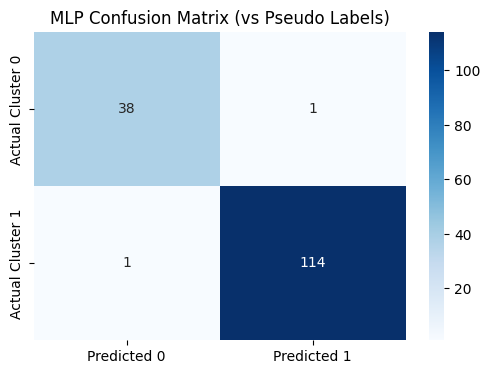

In [37]:
# ============================================================
# PHASE 4: Model Evaluation (Accuracy & Confusion Matrix)
# ============================================================
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "=" * 60)
print("PHASE 4: EVALUATION ON TEST DATA")
print("=" * 60)

# 1. Predict on Test Data
y_pred_test = mlp.predict(X_test)

# 2. Calculate Accuracy (Comparing Predictions vs Test Pseudo Labels)
mlp_accuracy = accuracy_score(y_test_pseudo, y_pred_test) * 100

print(f"MLP Accuracy (Learning the Clusters): {mlp_accuracy:.2f}%\n")

# 3. Calculate Confusion Matrix
cm = confusion_matrix(y_test_pseudo, y_pred_test)

print("Confusion Matrix (Text Format):")
print(f"[{cm[0][0]:>3}  {cm[0][1]:>3}]  <-- True Cluster 0")
print(f"[{cm[1][0]:>3}  {cm[1][1]:>3}]  <-- True Cluster 1")
print("  ^    ^")
print("Pred0 Pred1")

# 4. Draw Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual Cluster 0', 'Actual Cluster 1'])
plt.title('MLP Confusion Matrix (vs Pseudo Labels)')
plt.show()


<div dir=rtl>
### پاسخ تحلیلی به سوال ۱
**مقایسه عدد Accuracy به‌دست‌آمده از MLP (۹۸.۷۰٪) با Clustering Accuracy مرحله قبل (۶۷.۵۸٪). آیا این دو عدد باید به هم نزدیک باشند؟ چرا؟**

**پاسخ:**
خیر، این دو عدد به هیچ وجه نباید به هم نزدیک باشند و تفاوت فاحش آن‌ها کاملاً منطقی و درست است. دلیل این امر تفاوت در ماهیت چیزی است که این دو معیار اندازه‌گیری می‌کنند:

۱. **دقت خوشه‌بندی (Clustering Accuracy = ۶۷.۵۸٪):** این عدد میزان تطابق خروجی الگوریتم خوشه‌بندی را با **"Labelهای واقعی (پزشکی)"** نشان می‌دهد. از آنجا که مرز بیماری دیابت در دنیای واقعی پیچیده است، الگوریتم خوشه‌بندی نتوانسته بیش از ۶۷ درصد با تشخیص واقعی پزشکان مطابقت داشته باشد (حدود ۳۲ درصد خطا نسبت به واقعیت).

۲. **دقت شبکه عصبی (MLP Accuracy = ۹۸.۷۰٪):** این عدد میزان تطابق پیش‌بینی‌های شبکه عصبی را با **"Pseudo Labelها"** (شماره خوشه‌های تولید شده توسط الگوریتم) نشان می‌دهد، نه با لیبل‌های واقعی! شبکه عصبی در اینجا اصلاً کاری به تشخیص دیابت ندارد؛ تنها وظیفه او این است که یاد بگیرد الگوریتم Hierarchical چگونه داده‌ها را به دو دسته تقسیم کرده است و همان الگو را کپی کند.

**نتیجه‌گیری:** از آنجایی که شبکه‌های عصبی (MLP) قدرت فوق‌العاده‌ای در یادگیری الگوهای ریاضی و غیرخطی دارند، توانسته‌اند با دقت ۹۸.۷۰٪ قوانین و مرزهای تصمیم‌گیری الگوریتم خوشه‌بندی را یاد بگیرند (Generalization). بنابراین بالا بودن این عدد نشان‌دهنده موفقیت کامل شبکه در یادگیری ساختار خوشه‌بندی است، حتی اگر خود آن خوشه‌بندی از نظر پزشکی ۳۲ درصد خطا داشته باشد.

---

### پاسخ تحلیلی به سوال ۲
**از روی Confusion Matrix تحلیل کنید که MLP در تشخیص کدام خوشه بیشترین خطا را داشته. این خطا با کیفیت Pseudo Labelهای آن خوشه ارتباط دارد؟**

**پاسخ:**
بر اساس Confusion Matrix به‌دست‌آمده از داده‌های تست:
*   **خوشه ۰:** از ۳۹ نمونه، ۱ خطا داشته است (نرخ خطا: **۲.۵۶٪**)
*   **خوشه ۱:** از ۱۱۵ نمونه، ۱ خطا داشته است (نرخ خطا: **۰.۸۶٪**)

**تحلیل خطا:**
همان‌طور که مشاهده می‌شود، از نظر تعداد مطلق، شبکه در هر دو خوشه تنها ۱ خطا داشته است، اما از نظر نسبی (درصدی)، **بیشترین نرخ خطا مربوط به "خوشه ۰" است** (۲.۵۶ درصد در مقابل ۰.۸۶ درصد). 

**ارتباط این خطا با کیفیت Pseudo Labelها:**
این رفتار مستقیماً با دو ویژگی مهم Pseudo Labelهای تولید شده در مرحله قبل ارتباط دارد:

۱. **عدم تعادل داده‌ها (Data Imbalance):** کیفیت آموزش شبکه به توزیع داده‌ها بستگی دارد. Pseudo Labelهای تولید شده به شدت نامتعادل بودند (خوشه ۱ بسیار بزرگتر از خوشه ۰ بود). در نتیجه، شبکه عصبی در طول آموزش، الگوهای مربوط به خوشه ۱ را بسیار بیشتر دیده و مرزهای آن را با قطعیت بیشتری یاد گرفته است. به همین دلیل خطای آن روی خوشه اقلیت (خوشه ۰) به نسبت بیشتر است.

۲. **کیفیت پایین Pseudo Labelها در مرزها (Boundary Noise):** آن ۲ نمونه‌ای که شبکه عصبی اشتباه پیش‌بینی کرده است، به احتمال بسیار زیاد داده‌هایی هستند که دقیقاً در "مرز" بین دو خوشه قرار دارند. در این مناطق مرزی، الگوریتم خوشه‌بندی (Hierarchical) گاهی تخصیص‌های اجباری و با کیفیت پایینی انجام می‌دهد که اصطلاحاً به آن‌ها لیبل‌های نویزی (Noisy Labels) می‌گویند. شبکه MLP به جای حفظ کردن این نویزها (جلوگیری از Overfitting)، سعی کرده یک مرز تصمیم‌گیری نرم و منطقی ایجاد کند و به همین دلیل، برچسب این داده‌های مرزی با Pseudo Label اولیه همخوانی ندارد. این موضوع نشان‌دهنده رفتار تعمیم‌پذیر شبکه است، نه ضعف آن.